# Demand Forecasting model

# Objective:
    To develop an end-to-end demand forecasting solution that leverages machine learning and time series analysis to predict customer demand, evaluate model performance, and provide actionable insights for inventory management and business operations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("demand_forecasting.csv")

In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [5]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [6]:
df["Epidemic"].value_counts()

Epidemic
0    60800
1    15200
Name: count, dtype: int64

In [7]:
df["Date"]=pd.to_datetime(df["Date"])
df["Date"].dtype

dtype('<M8[us]')

In [8]:
df.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [11]:
df.describe(include="object").T

,count,unique,top,freq
Store ID,76000,5,S001,15200
Product ID,76000,20,P0001,3800
Category,76000,5,Groceries,30400
Region,76000,4,North,30400
Weather Condition,76000,4,Cloudy,24360
Seasonality,76000,4,Winter,21000


# Feature engineering

In [12]:
df["Year"]= df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df.head(2)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1


In [13]:
df["Year"].value_counts()

Year
2022    36500
2023    36500
2024     3000
Name: count, dtype: int64

In [14]:
df.tail()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64,2024,1
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137,2024,1
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68,2024,1
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84,2024,1
75999,2024-01-30,S005,P0020,Toys,North,126,63,59,25.78,10,Snowy,0,29.32,Winter,0,73,2024,1


In [15]:
df["Day"]= df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()
df.head(2)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday


In [16]:
df["Discounted_price"]= df["Price"]*(1-df["Discount"]/100)
df.head(2)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted_price
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,0,85.73,Winter,0,115,2022,1,1,Saturday,69.084
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,1,92.02,Winter,0,229,2022,1,1,Saturday,68.136


In [17]:
df["Sell through Rate"]= df["Units Sold"]/ df["Inventory Level"]
df["Sell through Rate"].describe()

count    75594.000000
mean         0.437580
std          0.298007
min          0.003150
25%          0.190807
50%          0.350475
75%          0.642276
max          1.000000
Name: Sell through Rate, dtype: float64

# Bussiness Insights

In [18]:
df.groupby("Category")["Demand"].agg(["mean","sum","std"]).sort_values(by="sum", ascending= False)

,mean,sum,std
Category,,,
Groceries,120.976447,3677684,48.362730
Clothing,112.619737,1369456,41.022968
Furniture,73.581140,1006590,32.336141
Toys,92.606955,985338,46.170390
Electronics,97.482018,889036,40.557859


In [19]:
df.groupby(["Region", "Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [20]:
df.groupby("Promotion")["Demand"].mean()

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

In [21]:
pd.pivot_table(df, values= "Demand" ,index = "Month", columns="Category", aggfunc="mean")

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


# Visual insights

In [22]:
plt.figure(figsize=(10,6))
sns.set(style="whitegrid")

<Figure size 1000x600 with 0 Axes>

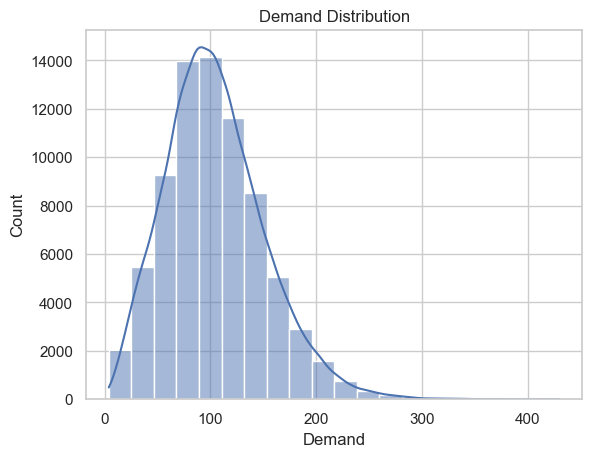

In [23]:
sns.histplot(df["Demand"], bins=20, kde=True)
plt.title("Demand Distribution")
plt.show()

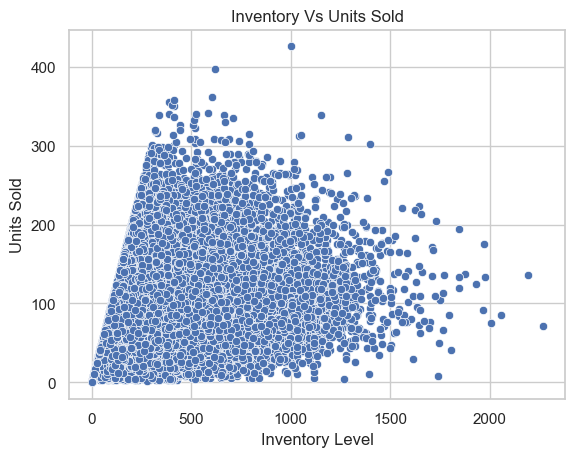

In [25]:
sns.scatterplot(data=df, x="Inventory Level", y="Units Sold")
plt.title("Inventory Vs Units Sold")
plt.show()

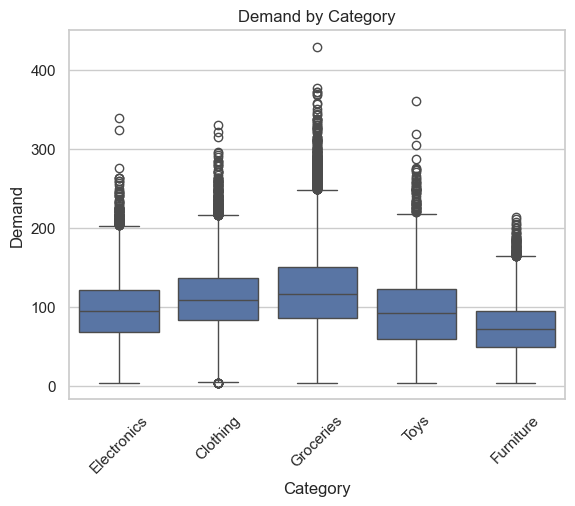

In [27]:
sns.boxplot(data= df, x="Category", y="Demand")
plt.xticks(rotation=45)
plt.title("Demand by Category")
plt.show()

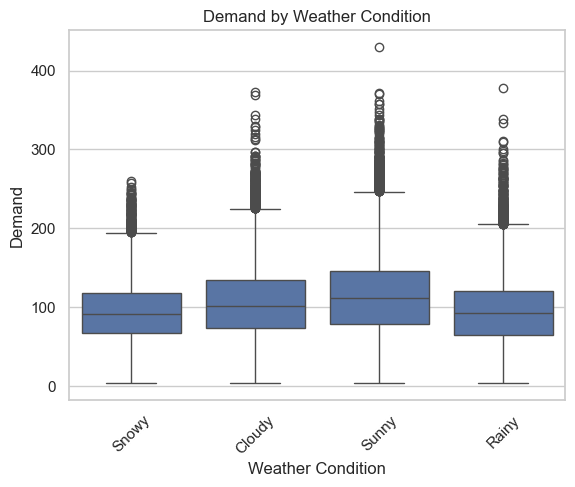

In [28]:
sns.boxplot(data= df, x="Weather Condition", y="Demand")
plt.xticks(rotation=45)
plt.title("Demand by Weather Condition")
plt.show()

In [29]:
Monthly_Demand=df.groupby("Month")["Demand"].mean()

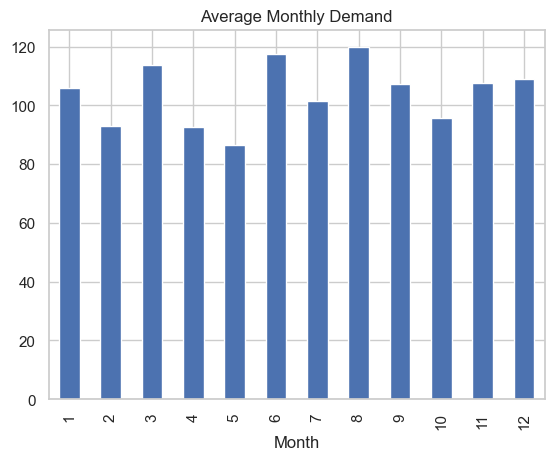

In [31]:
Monthly_Demand.plot(kind="bar")
plt.title("Average Monthly Demand")
plt.show()

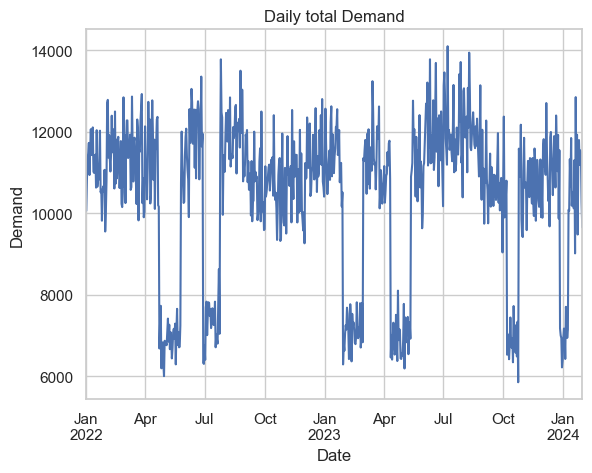

In [32]:
Daily_Demand=df.groupby("Date")["Demand"].sum()
Daily_Demand.plot()
plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Daily total Demand")
plt.show()


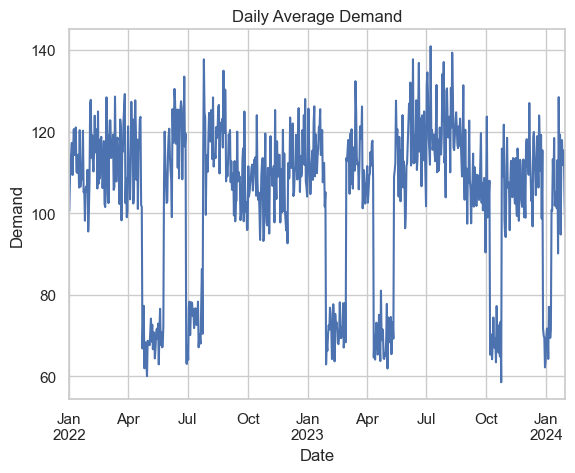

In [33]:
Daily_Demand=df.groupby("Date")["Demand"].mean()
Daily_Demand.plot()
plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Daily Average Demand")
plt.show()

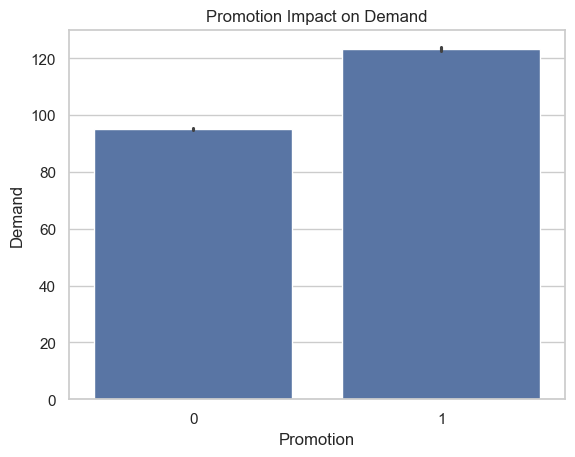

In [37]:
sns.barplot(data=df, x="Promotion", y="Demand")
plt.title("Promotion Impact on Demand")
plt.show()

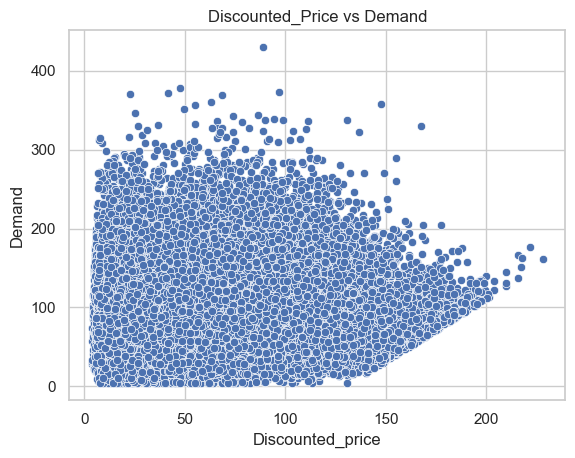

In [42]:
sns.scatterplot(data=df, x="Discounted_price", y="Demand")
plt.title("Discounted_Price vs Demand")
plt.show()